In [2]:
!pip install neuprint-python navis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from scipy.stats import spearmanr, pearsonr
from neuprint import Client, fetch_synapse_connections, fetch_adjacencies, NeuronCriteria as NC
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [4]:

# Read authentication token
from google.colab import userdata
auth_token = userdata.get('NEUPRINT_TOKEN')

# Connect to Neuprint
np_client = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=auth_token)
print(f"Connected to neuprint.janelia.org (hemibrain:v1.2.1)")

Connected to neuprint.janelia.org (hemibrain:v1.2.1)


In [5]:
print("Querying Hemibrain for True Hubs (by UNIQUE presynaptic partners)...")

# This Cypher query explicitly counts DISTINCT presynaptic body IDs.
cypher_query = """
MATCH (pre:Neuron)-[:ConnectsTo]->(post:Neuron {status: 'Traced', cropped: false})
RETURN post.bodyId AS bodyId, post.type AS type, count(DISTINCT pre.bodyId) AS unique_in_degree
ORDER BY unique_in_degree DESC
LIMIT 50
"""
hubs_df = np_client.fetch_custom(cypher_query)

print("\nTop 10 True Hubs:")
display(hubs_df.head(10))

# Let's take the #1 Hub to start our pipeline
TARGET_HUB = hubs_df.iloc[0]['bodyId']
TARGET_TYPE = hubs_df.iloc[0]['type']
print(f"\n---> Selected Target Hub: {TARGET_HUB} ({TARGET_TYPE})")

Querying Hemibrain for True Hubs (by UNIQUE presynaptic partners)...

Top 10 True Hubs:


,bodyId,type,unique_in_degree
0,2124762952,mALC2,4388
1,425790257,APL,3146
2,329566174,OA-VPM3,3119
3,1640909284,lLN2F_b,3020
4,425276848,DPM,2997
5,5901218894,lLN2F_a,2774
6,5813024698,lLN2F_b,2748
7,1670287030,lLN2F_a,2699
8,1628523730,mALC1,2679
9,1343403608,None,2654



---> Selected Target Hub: 2124762952 (mALC2)


Fetching synapses for Hub 2124762952...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/19584 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Calculating physical centroids for each presynaptic neuron...
Found 4388 unique presynaptic neurons.
Fetching connections between these presynaptic neurons...


  0%|          | 0/22 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Calculating physical distances between all neuron pairs...
Merging data and plotting...
Total possible pairs: 9,625,078
Actually connected pairs: 10,663


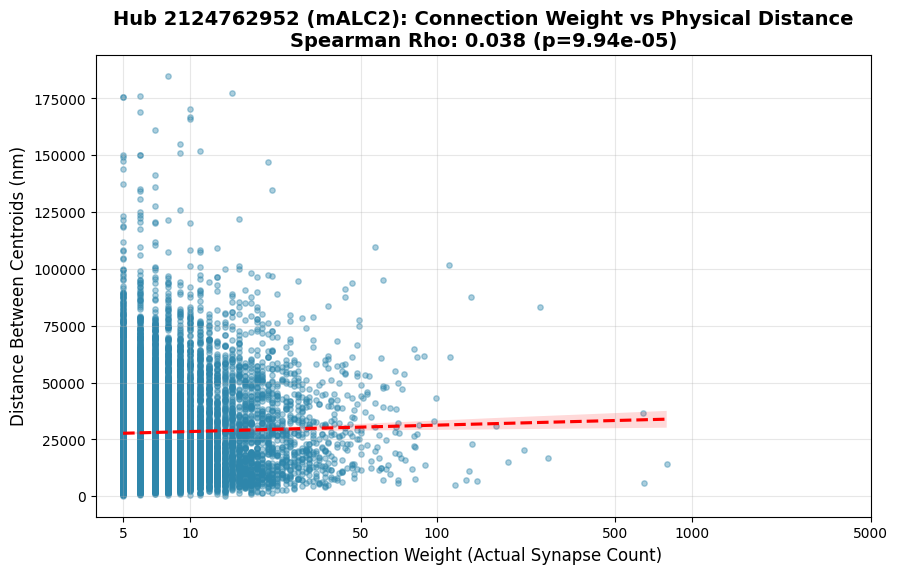

In [25]:
# ==========================================
# PHASE 2: Get Synapses & Centroids
# ==========================================
print(f"Fetching synapses for Hub {TARGET_HUB}...")
synapses_df = fetch_synapse_connections(None, TARGET_HUB)

# Keep only synapses going INTO the hub
synapses_df = synapses_df[synapses_df['bodyId_post'] == TARGET_HUB].copy()

# Calculate the 3D Centroid for EVERY individual presynaptic neuron
print("Calculating physical centroids for each presynaptic neuron...")
centroids_df = synapses_df.groupby('bodyId_pre')[['x_pre', 'y_pre', 'z_pre']].mean()
pre_neurons = centroids_df.index.tolist()

print(f"Found {len(pre_neurons)} unique presynaptic neurons.")

# ==========================================
# PHASE 3: Fetch Subconnectome (Weights)
# ==========================================
print("Fetching connections between these presynaptic neurons...")
_, edges_df = fetch_adjacencies(NC(bodyId=pre_neurons), NC(bodyId=pre_neurons))

# We want UNDIRECTED weights (A->B + B->A) so we don't treat A-B and B-A as different pairs
# By taking the minimum/maximum of the body IDs to create an undirected pair (neuron_1 and neuron_2)
# and then using .groupby().sum(), its automatically aggregating both A → B and B → A connections and
# summing across all ROIs simultaneously.
edges_df['neuron_1'] = np.minimum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
edges_df['neuron_2'] = np.maximum(edges_df['bodyId_pre'], edges_df['bodyId_post'])

# Sum weights for each unique pair
weights_df = edges_df.groupby(['neuron_1', 'neuron_2'], as_index=False)['weight'].sum()

# ==========================================
# PHASE 4: Calculate Pairwise Distances
# ==========================================
print("Calculating physical distances between all neuron pairs...")
# Calculate distances between all centroids
distances = pdist(centroids_df.values, metric='euclidean')

# Create a DataFrame of all possible pairs and their distances
pairs = list(combinations(centroids_df.index, 2))
distances_df = pd.DataFrame(pairs, columns=['neuron_1', 'neuron_2'])

# Ensure neuron_1 is always the smaller ID so it matches our weights_df
distances_df['n1_temp'] = np.minimum(distances_df['neuron_1'], distances_df['neuron_2'])
distances_df['n2_temp'] = np.maximum(distances_df['neuron_1'], distances_df['neuron_2'])
distances_df['neuron_1'] = distances_df['n1_temp']
distances_df['neuron_2'] = distances_df['n2_temp']
distances_df = distances_df.drop(columns=['n1_temp', 'n2_temp'])

distances_df['distance_nm'] = distances * 8 # Hemibrain voxels are 8x8x8 nm

# ==========================================
# PHASE 5: Merge & Plot
# ==========================================
print("Merging data and plotting...")
# Merge weights into the distance dataframe
# Pairs that don't exist in weights_df will get NaN, which we fill with 0
final_df = distances_df.merge(weights_df, on=['neuron_1', 'neuron_2'], how='left')
final_df['weight'] = final_df['weight'].fillna(0)

# FILTER: We only want to plot pairs that ACTUALLY connect to each other (weight >= 5)
connected_pairs = final_df[final_df['weight'] >= 5].copy()
connected_pairs['log_weight'] = np.log1p(connected_pairs['weight'])

print(f"Total possible pairs: {len(final_df):,}")
print(f"Actually connected pairs: {len(connected_pairs):,}")

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=connected_pairs,
    x='log_weight',
    y='distance_nm',
    scatter_kws={'alpha':0.4, 's':15, 'color':'#2E86AB'},
    line_kws={'color':'red', 'linestyle':'--'}
)

# Statistics
rho, p_val = spearmanr(connected_pairs['log_weight'], connected_pairs['distance_nm'])

plt.title(f"Hub {TARGET_HUB} ({TARGET_TYPE}): Connection Weight vs Physical Distance\nSpearman Rho: {rho:.3f} (p={p_val:.2e})", fontsize=14, fontweight='bold')
plt.xlabel("Connection Weight (log1p)", fontsize=12)
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
actual_weights =[5, 10, 50, 100, 500, 1000, 5000]
log_ticks = np.log1p(actual_weights)
plt.xticks(ticks=log_ticks, labels=actual_weights)
plt.xlabel("Connection Weight (Actual Synapse Count)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from multiprocessing import Pool, cpu_count
from neuprint import fetch_simple_connections

def process_single_hub(hub_id):
    try:
        synapses_df = fetch_synapse_connections(None, hub_id)
        synapses_df = synapses_df[synapses_df['bodyId_post'] == hub_id].copy()

        if len(synapses_df) == 0:
            return None

        centroids_df = synapses_df.groupby('bodyId_pre')[['x_pre', 'y_pre', 'z_pre']].mean()
        pre_neurons = centroids_df.index.tolist()

        if len(pre_neurons) < 2:
            return None

        edges_df = fetch_simple_connections(NC(bodyId=pre_neurons), NC(bodyId=pre_neurons))

        if edges_df is None or len(edges_df) == 0:
            return None

        edges_df['neuron_1'] = np.minimum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
        edges_df['neuron_2'] = np.maximum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
        weights_df = edges_df.groupby(['neuron_1', 'neuron_2'], as_index=False)['weight'].sum()

        connected_only = weights_df[weights_df['weight'] >= 5].copy()

        if len(connected_only) == 0:
            return None

        connected_only = connected_only.merge(
            centroids_df, left_on='neuron_1', right_index=True, how='inner'
        ).rename(columns={'x_pre': 'x1', 'y_pre': 'y1', 'z_pre': 'z1'})

        connected_only = connected_only.merge(
            centroids_df, left_on='neuron_2', right_index=True, how='inner'
        ).rename(columns={'x_pre': 'x2', 'y_pre': 'y2', 'z_pre': 'z2'})

        dx = connected_only['x2'] - connected_only['x1']
        dy = connected_only['y2'] - connected_only['y1']
        dz = connected_only['z2'] - connected_only['z1']

        connected_only['distance_nm'] = np.sqrt(dx**2 + dy**2 + dz**2) * 8

        connected_only = connected_only[['neuron_1', 'neuron_2', 'weight', 'distance_nm']].copy()

        connected_only['hub_bodyId'] = hub_id

        return connected_only

    except Exception as e:
        return None

hub_list = hubs_df['bodyId'].tolist()
n_workers = min(16, cpu_count())

print(f"Processing {len(hub_list)} hubs using {n_workers} parallel workers...")

with Pool(n_workers) as pool:
    results = list(tqdm(
        pool.imap(process_single_hub, hub_list),
        total=len(hub_list),
        desc="Processing Hubs"
    ))

all_connected_pairs =[res for res in results if res is not None and not res.empty]

print("\nPooling data...")
final_pooled_df = pd.concat(all_connected_pairs, ignore_index=True)

final_pooled_df['log_weight'] = np.log1p(final_pooled_df['weight'])

print(f"Total connected pairs pooled across {len(hub_list)} hubs: {len(final_pooled_df):,}")

rho, p_val_spearman = spearmanr(final_pooled_df['log_weight'], final_pooled_df['distance_nm'])
r_p, p_val_pearson = pearsonr(final_pooled_df['log_weight'], final_pooled_df['distance_nm'])

print("\n--- POOLED STATISTICS ---")
print(f"Spearman Rho: {rho:.4f} (p = {p_val_spearman:.2e})")
print(f"Pearson R:    {r_p:.4f} (p = {p_val_pearson:.2e})")

Processing 50 hubs using 2 parallel workers...


Processing Hubs:   0%|          | 0/50 [00:00<?, ?it/s]


Pooling data...
Total connected pairs pooled across 50 hubs: 1,833,459

--- POOLED STATISTICS ---
Spearman Rho: 0.0808 (p = 0.00e+00)
Pearson R:    0.0323 (p = 0.00e+00)


In [8]:
# --- Plotting ---
plt.figure(figsize=(12, 7))

# Define the actual raw weight values you want to show on the axis
actual_weights =[5, 10, 50, 100, 500, 1000, 5000]

# Calculate their log1p equivalents for physical placement on the graph
log_ticks = np.log1p(actual_weights)

# We use a slight transparency (alpha) because millions of points will overlap
sns.regplot(
    data=final_pooled_df,
    x='log_weight',
    y='distance_nm',
    scatter_kws={'alpha':0.2, 's':10, 'color':'#2E86AB'},
    line_kws={'color':'red', 'linestyle':'--', 'linewidth': 3}
)

plt.title(f"Brain-Wide Hub Inputs: Connection Weight vs Physical Distance\n(Pooled across Top {len(hub_list)} Hubs | n={len(final_pooled_df):,} pairs)\nSpearman Rho: {rho:.3f} | Pearson R: {r_p:.3f}", fontsize=14, fontweight='bold')
plt.xticks(ticks=log_ticks, labels=actual_weights)
plt.xlabel("Connection Weight (Actual Synapse Count)", fontsize=12)
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d332cee09a0> (for post_execute):


KeyboardInterrupt: 

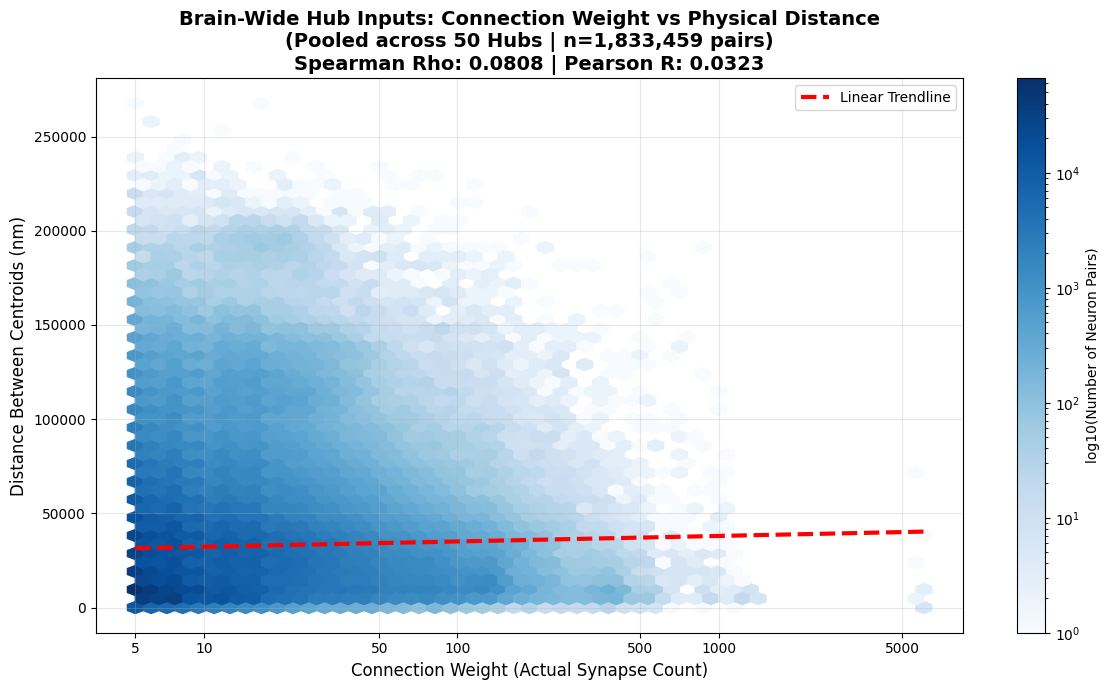

In [9]:
plt.figure(figsize=(12, 7))

# 1. Use a Hexbin plot to handle 7.6 million points instantly
# (Darker hexagons = more overlapping pairs in that region)
hb = plt.hexbin(
    final_pooled_df['log_weight'],
    final_pooled_df['distance_nm'],
    gridsize=50,
    cmap='Blues',
    mincnt=1,
    bins='log' # Log color scale so we can see the less dense areas
)
cb = plt.colorbar(hb)
cb.set_label('log10(Number of Neuron Pairs)')

# 2. Calculate and draw the trendline manually
m, b = np.polyfit(final_pooled_df['log_weight'], final_pooled_df['distance_nm'], 1)
x_line = np.linspace(final_pooled_df['log_weight'].min(), final_pooled_df['log_weight'].max(), 100)
plt.plot(x_line, m*x_line + b, color='red', linestyle='--', linewidth=3, label="Linear Trendline")

plt.title(f"Brain-Wide Hub Inputs: Connection Weight vs Physical Distance\n(Pooled across 50 Hubs | n={len(final_pooled_df):,} pairs)\nSpearman Rho: {rho:.4f} | Pearson R: {r_p:.4f}", fontsize=14, fontweight='bold')
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
plt.legend()
actual_weights =[5, 10, 50, 100, 500, 1000, 5000]
log_ticks = np.log1p(actual_weights)
plt.xticks(ticks=log_ticks, labels=actual_weights)
plt.xlabel("Connection Weight (Actual Synapse Count)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== POSTER FIGURE: 2D SYNAPSE CLUSTERS ON HUB SKELETON ===
[1] TARGET_HUB = 2124762952
[1] pre1 = 1343403608
[1] pre2 = 5813061218
[2] Fetching skeleton for Hub 2124762952...
[2] Skeleton fetched: 75119 nodes
[3] syns_pre1 count: 268
[3] syns_pre2 count: 793
[4] Centroid pre1: [ 5130.5858209  15247.03731343 28475.02985075]
[4] Centroid pre2: [ 4455.5334174  15527.70617907 28351.15762926]


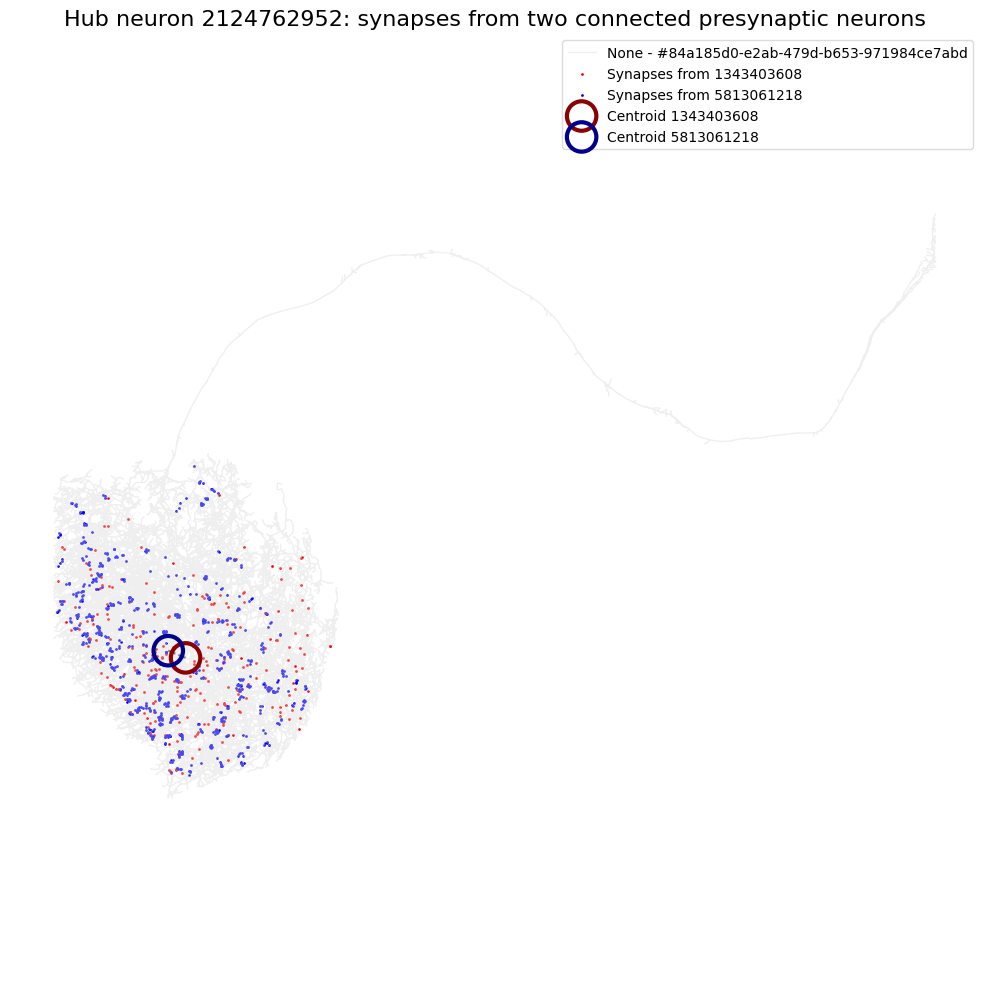

=== DONE ===


In [29]:
import navis
import matplotlib.pyplot as plt
import numpy as np
from neuprint import fetch_skeleton

print("=== POSTER FIGURE: 2D SYNAPSE CLUSTERS ON HUB SKELETON ===")

# --------------------------------------------------
# 1. Use the SAME example as in the first part
# --------------------------------------------------
sample_edge = best_candidates.iloc[0]
pre1 = int(sample_edge['neuron_1'])
pre2 = int(sample_edge['neuron_2'])

# Assumes TARGET_HUB is already the original hub from the first part
print(f"[1] TARGET_HUB = {TARGET_HUB}")
print(f"[1] pre1 = {pre1}")
print(f"[1] pre2 = {pre2}")

# --------------------------------------------------
# 2. Fetch hub skeleton
# --------------------------------------------------
print(f"[2] Fetching skeleton for Hub {TARGET_HUB}...")
skel_df = fetch_skeleton(TARGET_HUB, heal=True)

if skel_df is None or len(skel_df) == 0:
    raise ValueError("Skeleton fetch failed or returned empty dataframe")

print(f"[2] Skeleton fetched: {skel_df.shape[0]} nodes")
hub_skel = navis.TreeNeuron(skel_df)

# --------------------------------------------------
# 3. Filter synapses from the two connected presynaptic neurons
# --------------------------------------------------
syns_pre1 = synapses_df[
    (synapses_df['bodyId_post'] == TARGET_HUB) &
    (synapses_df['bodyId_pre'] == pre1)
].copy()

syns_pre2 = synapses_df[
    (synapses_df['bodyId_post'] == TARGET_HUB) &
    (synapses_df['bodyId_pre'] == pre2)
].copy()

print(f"[3] syns_pre1 count: {len(syns_pre1)}")
print(f"[3] syns_pre2 count: {len(syns_pre2)}")

if len(syns_pre1) == 0 or len(syns_pre2) == 0:
    raise ValueError("One of the selected presynaptic neurons has no synapses on this hub")

# --------------------------------------------------
# 4. Compute centroids of the two synapse groups
# --------------------------------------------------
cent1 = syns_pre1[['x_pre', 'y_pre', 'z_pre']].mean().values
cent2 = syns_pre2[['x_pre', 'y_pre', 'z_pre']].mean().values

print(f"[4] Centroid pre1: {cent1}")
print(f"[4] Centroid pre2: {cent2}")

# --------------------------------------------------
# 5. Build poster-friendly 2D figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Full hub skeleton as light background / outline
navis.plot2d(
    hub_skel,
    ax=ax,
    color='lightgray',
    alpha=0.35,
    soma=False
)

# Synapses from pre1
ax.scatter(
    syns_pre1['x_pre'],
    syns_pre1['y_pre'],
    color='red',
    s=1,
    alpha=0.95,
    label=f'Synapses from {pre1}',
    zorder=1
)

# Synapses from pre2
ax.scatter(
    syns_pre2['x_pre'],
    syns_pre2['y_pre'],
    color='blue',
    s=1,
    alpha=0.95,
    label=f'Synapses from {pre2}',
    zorder=1
)

# Centroid 1
ax.scatter(
    cent1[0],
    cent1[1],
    facecolors='none',
    edgecolors='darkred',
    s=450,
    marker='o',
    linewidth=3,
    label=f'Centroid {pre1}',
    zorder=10
)

# Centroid 2
ax.scatter(
    cent2[0],
    cent2[1],
    facecolors='none',
    edgecolors='darkblue',
    s=450,
    marker='o',
    linewidth=3,
    label=f'Centroid {pre2}',
    zorder=10
)

# Optional: connect centroid to centroid for readability
ax.plot(
    [cent1[0], cent2[0]],
    [cent1[1], cent2[1]],
    linestyle='--',
    linewidth=1.5,
    color='black',
    alpha=0.5,
    zorder=8
)

# --------------------------------------------------
# 6. Zoom around the synapse region so it looks good on a poster
# --------------------------------------------------
all_x = np.concatenate([
    syns_pre1['x_pre'].to_numpy(),
    syns_pre2['x_pre'].to_numpy(),
    np.array([cent1[0], cent2[0]])
])

all_y = np.concatenate([
    syns_pre1['y_pre'].to_numpy(),
    syns_pre2['y_pre'].to_numpy(),
    np.array([cent1[1], cent2[1]])
])

buffer = 1200

ax.set_xlim(all_x.min() - buffer, all_x.max() + buffer)
ax.set_ylim(all_y.min() - buffer, all_y.max() + buffer)

# --------------------------------------------------
# 7. Clean styling for poster
# --------------------------------------------------
ax.axis('equal')
ax.axis('off')

plt.title(
    f"Hub neuron {TARGET_HUB}: synapses from two connected presynaptic neurons",
    fontsize=16
)

plt.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)

plt.tight_layout()
plt.show()

print("=== DONE ===")

In [21]:
import pandas as pd

syn_counts = (
    synapses_df
    .groupby(['bodyId_post', 'bodyId_pre'])
    .size()
    .reset_index(name='syn_count')
)

all_rows = []

for _, pair in connected_pairs.iterrows():
    n1 = pair['neuron_1']
    n2 = pair['neuron_2']

    n1_counts = syn_counts[syn_counts['bodyId_pre'] == n1][['bodyId_post', 'syn_count']].rename(
        columns={'syn_count': 'syn_count_1'}
    )
    n2_counts = syn_counts[syn_counts['bodyId_pre'] == n2][['bodyId_post', 'syn_count']].rename(
        columns={'syn_count': 'syn_count_2'}
    )

    merged = n1_counts.merge(n2_counts, on='bodyId_post', how='inner')

    if len(merged) > 0:
        merged['neuron_1'] = n1
        merged['neuron_2'] = n2
        merged['hub'] = merged['bodyId_post']
        merged['total_syn'] = merged['syn_count_1'] + merged['syn_count_2']
        merged['min_syn'] = merged[['syn_count_1', 'syn_count_2']].min(axis=1)
        merged['product_syn'] = merged['syn_count_1'] * merged['syn_count_2']
        all_rows.append(
            merged[['hub', 'neuron_1', 'neuron_2', 'syn_count_1', 'syn_count_2', 'total_syn', 'min_syn', 'product_syn']]
        )

best_candidates = pd.concat(all_rows, ignore_index=True)

best_candidates = best_candidates.sort_values(
    by=['min_syn', 'total_syn', 'product_syn'],
    ascending=False
).reset_index(drop=True)

print(best_candidates.head(20))

           hub      neuron_1      neuron_2  syn_count_1  syn_count_2  \
0   2124762952  1.343404e+09  5.813061e+09          268          793   
1   2124762952  5.813061e+09  5.813061e+09          255          793   
2   2124762952  1.343404e+09  5.813061e+09          268          255   
3   2124762952  9.126012e+08  1.343404e+09          211          268   
4   2124762952  6.978827e+08  5.813061e+09          140          255   
5   2124762952  6.978827e+08  9.126012e+08          140          211   
6   2124762952  1.904117e+09  5.813061e+09           44          255   
7   2124762952  9.126012e+08  1.904117e+09          211           44   
8   2124762952  2.309272e+09  5.813061e+09           42          793   
9   2124762952  1.255138e+09  5.813061e+09           42          255   
10  2124762952  9.126012e+08  1.255138e+09          211           42   
11  2124762952  1.658886e+09  5.813061e+09           40          255   
12  2124762952  9.126012e+08  1.658886e+09          211         

In [22]:
sample_edge = best_candidates.iloc[0]
TARGET_HUB = int(sample_edge['hub'])
pre1 = sample_edge['neuron_1']
pre2 = sample_edge['neuron_2']

print("Using better visual example:")
print(sample_edge)

Using better visual example:
hub            2.124763e+09
neuron_1       1.343404e+09
neuron_2       5.813061e+09
syn_count_1    2.680000e+02
syn_count_2    7.930000e+02
total_syn      1.061000e+03
min_syn        2.680000e+02
product_syn    2.125240e+05
Name: 0, dtype: float64


In [24]:
import navis
import plotly.graph_objects as go
from neuprint import fetch_skeleton
import numpy as np

print("=== TOP-OPTION VIS ===")

# --------------------------------------------------
# 1. Use the top-ranked candidate from best_candidates
# --------------------------------------------------
sample_edge = best_candidates.iloc[0]

TARGET_HUB = int(sample_edge['hub'])
pre1 = int(sample_edge['neuron_1'])
pre2 = int(sample_edge['neuron_2'])

print(f"[1] TARGET_HUB = {TARGET_HUB}")
print(f"[1] pre1 = {pre1}")
print(f"[1] pre2 = {pre2}")
print(f"[1] syn_count_1 = {int(sample_edge['syn_count_1'])}")
print(f"[1] syn_count_2 = {int(sample_edge['syn_count_2'])}")

# --------------------------------------------------
# 2. Fetch skeleton for the hub
# --------------------------------------------------
print(f"[2] Fetching skeleton for Hub {TARGET_HUB}...")
skel_df = fetch_skeleton(TARGET_HUB, heal=True)

if skel_df is None or len(skel_df) == 0:
    raise ValueError("Skeleton fetch failed or returned empty dataframe")

print(f"[2] Skeleton fetched: {skel_df.shape[0]} nodes")
hub_skel = navis.TreeNeuron(skel_df)

# --------------------------------------------------
# 3. Filter synapses for the selected hub + pair
# --------------------------------------------------
syns_pre1 = synapses_df[
    (synapses_df['bodyId_post'] == TARGET_HUB) &
    (synapses_df['bodyId_pre'] == pre1)
].copy()

syns_pre2 = synapses_df[
    (synapses_df['bodyId_post'] == TARGET_HUB) &
    (synapses_df['bodyId_pre'] == pre2)
].copy()

print(f"[3] syns_pre1 count: {len(syns_pre1)}")
print(f"[3] syns_pre2 count: {len(syns_pre2)}")

if len(syns_pre1) == 0 or len(syns_pre2) == 0:
    raise ValueError("One of the selected presynaptic neurons has no synapses on this hub")

# --------------------------------------------------
# 4. Compute centroids
# --------------------------------------------------
cent1 = syns_pre1[['x_pre', 'y_pre', 'z_pre']].mean().values
cent2 = syns_pre2[['x_pre', 'y_pre', 'z_pre']].mean().values

print(f"[4] Centroid pre1: {cent1}")
print(f"[4] Centroid pre2: {cent2}")

# --------------------------------------------------
# 5. Build figure
# --------------------------------------------------
fig = go.Figure()

# Add hub skeleton
navis.plot3d(
    hub_skel,
    backend='plotly',
    fig=fig,
    color='lightgray',
    alpha=0.35,
    soma=False
)

print(f"[5] Traces after skeleton: {len(fig.data)}")

# Make skeleton thicker
if len(fig.data) > 0:
    try:
        fig.data[0].line.width = 4
        print(f"[5] Skeleton line width set to {fig.data[0].line.width}")
    except Exception as e:
        print(f"[5] Could not set skeleton line width: {e}")

# Add synapses for pre1
fig.add_trace(go.Scatter3d(
    x=syns_pre1['x_pre'],
    y=syns_pre1['y_pre'],
    z=syns_pre1['z_pre'],
    mode='markers',
    name=f'Pre1 synapses ({pre1})',
    marker=dict(
        color='red',
        size=1,
        opacity=0.9
    )
))

# Add synapses for pre2
fig.add_trace(go.Scatter3d(
    x=syns_pre2['x_pre'],
    y=syns_pre2['y_pre'],
    z=syns_pre2['z_pre'],
    mode='markers',
    name=f'Pre2 synapses ({pre2})',
    marker=dict(
        color='blue',
        size=1,
        opacity=0.9
    )
))

# Add centroid for pre1
fig.add_trace(go.Scatter3d(
    x=[cent1[0]],
    y=[cent1[1]],
    z=[cent1[2]],
    mode='markers',
    name=f'Centroid pre1 ({pre1})',
    marker=dict(
        color='darkred',
        size=12,
        symbol='diamond'
    )
))

# Add centroid for pre2
fig.add_trace(go.Scatter3d(
    x=[cent2[0]],
    y=[cent2[1]],
    z=[cent2[2]],
    mode='markers',
    name=f'Centroid pre2 ({pre2})',
    marker=dict(
        color='darkblue',
        size=12,
        symbol='diamond'
    )
))

print(f"[6] Total traces before layout: {len(fig.data)}")
for i, trace in enumerate(fig.data):
    try:
        n_points = len(trace.x) if trace.x is not None else 0
    except Exception:
        n_points = "unknown"
    print(f"    Trace {i}: {trace.name}, points={n_points}")

# --------------------------------------------------
# 6. Layout
# --------------------------------------------------
fig.update_layout(
    title=(
        f"Top Hub Visualization<br>"
        f"Hub {TARGET_HUB}<br>"
        f"Pre1={pre1} ({len(syns_pre1)} synapses), "
        f"Pre2={pre2} ({len(syns_pre2)} synapses)"
    ),
    scene=dict(
        xaxis=dict(showbackground=False, showgrid=False, zeroline=False, showticklabels=False, title=''),
        yaxis=dict(showbackground=False, showgrid=False, zeroline=False, showticklabels=False, title=''),
        zaxis=dict(showbackground=False, showgrid=False, zeroline=False, showticklabels=False, title=''),
        aspectmode='data'
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=0, r=0, b=0, t=90),
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor='rgba(255,255,255,0.8)'
    )
)

print("[7] Showing figure...")
fig.show()
print("=== DONE ===")

=== TOP-OPTION VIS ===
[1] TARGET_HUB = 2124762952
[1] pre1 = 1343403608
[1] pre2 = 5813061218
[1] syn_count_1 = 268
[1] syn_count_2 = 793
[2] Fetching skeleton for Hub 2124762952...
[2] Skeleton fetched: 75119 nodes
[3] syns_pre1 count: 268
[3] syns_pre2 count: 793
[4] Centroid pre1: [ 5130.5858209  15247.03731343 28475.02985075]
[4] Centroid pre2: [ 4455.5334174  15527.70617907 28351.15762926]


[5] Traces after skeleton: 1
[5] Skeleton line width set to 4
[6] Total traces before layout: 5
    Trace 0: navis.TreeNeuron, points=90990
    Trace 1: Pre1 synapses (1343403608), points=268
    Trace 2: Pre2 synapses (5813061218), points=793
    Trace 3: Centroid pre1 (1343403608), points=1
    Trace 4: Centroid pre2 (5813061218), points=1
[7] Showing figure...


=== DONE ===
